# 06 · Career ladder, headroom what-if, Capability Evidence Matrix & decision engine
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. Career intelligence — Data Science Jobs: structural senior/junior pay ladder (company-paired)

In [2]:
from scipy.stats import wilcoxon
DS = pd.read_csv(f"{DATA_DIR}/DataScience_Jobs.csv")
for c in ["avg_salary","min_salary","max_salary"]: DS[c] = DS[c].str.replace("L","").astype(float)
print("ordering violations (min<=avg<=max):", int(((DS.min_salary > DS.avg_salary) | (DS.avg_salary > DS.max_salary)).sum()))
print(DS.groupby("job_title").agg(rows=("company_name","size"), median_avg_LPA=("avg_salary","median"), median_min_exp=("min_experience","median"), total_postings=("num_of_jobs","sum")).sort_values("median_avg_LPA", ascending=False).round(1).to_string())
rng = np.random.default_rng(SEED); ladder = {}
for base in ["Data Scientist","Data Analyst","Data Engineer","Business Analyst"]:
    j = DS[DS.job_title==base].set_index("company_name").avg_salary; s = DS[DS.job_title==f"Senior {base}"].set_index("company_name").avg_salary
    pair = pd.concat([j.rename("jr"), s.rename("sr")], axis=1, join="inner").dropna(); ratio = (pair.sr/pair.jr).values
    boots = [np.median(rng.choice(ratio, len(ratio))) for _ in range(2000)]
    w = wilcoxon(pair.sr, pair.jr, alternative="greater")
    ladder[base] = dict(median_ratio=float(np.median(ratio)), lo=float(np.percentile(boots,2.5)), hi=float(np.percentile(boots,97.5)), n=len(pair), share_senior_higher=float((ratio>1).mean()), wilcoxon_p=float(w.pvalue))
    print(f"{base:17s} median sr/jr = {ladder[base]['median_ratio']:.2f} [{ladder[base]['lo']:.2f},{ladder[base]['hi']:.2f}]  companies={len(pair)}  senior higher in {ladder[base]['share_senior_higher']:.0%}  Wilcoxon p={w.pvalue:.1e}")
save_res("ladder", ladder)

ordering violations (min<=avg<=max): 0
                           rows  median_avg_LPA  median_min_exp  total_postings
job_title                                                                      
Data Architect               50            24.2            10.0             528
Senior Data Scientist       185            21.2             4.0            2129
Senior Data Engineer        183            17.6             4.0            3411
Senior Business Analyst     187            13.0             4.0           14115
Data Scientist              188            12.8             2.0            9051
Data Engineer               188            10.9             1.0            8044
Machine Learning Engineer    59             9.1             1.0             964
Senior Data Analyst         187             8.6             3.0            3825
Business Analyst            188             8.3             2.0           32843
Data Analyst                187             5.0             1.0           18095
D

In [3]:
# Salary model on the DS Jobs file: what explains avg pay? (grouped by company so a company never sits in train and test)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
top = DS.company_name.value_counts().head(40).index; DS["company_top"] = np.where(DS.company_name.isin(top), DS.company_name, "Other")
DS["log_jobs"] = np.log1p(DS.num_of_jobs); y = np.log(DS.avg_salary.values); g = DS.company_name.astype("category").cat.codes.values
def pipe(cats, nums, model): return Pipeline([("p", ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore"), cats), ("n", "passthrough", nums)])), ("m", model)])
cands = {"Title-only Ridge": pipe(["job_title"], [], Ridge(1.0)), "Title+exp Ridge": pipe(["job_title"], ["min_experience"], Ridge(1.0)),
         "Title+exp+demand+company Ridge": pipe(["job_title","company_top"], ["min_experience","log_jobs"], Ridge(3.0)),
         "Gradient boosting": pipe(["job_title","company_top"], ["min_experience","log_jobs"], GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=SEED))}
ds_models = {}
for n, m in cands.items():
    p = cross_val_predict(m, DS, y, groups=g, cv=GroupKFold(5)); ds_models[n] = dict(r2=float(r2_score(y, p)), mae_lpa=float(mean_absolute_error(np.exp(y), np.exp(p))))
    print(f"{n:34s} R²={ds_models[n]['r2']:.3f}  MAE={ds_models[n]['mae_lpa']:.2f} LPA")
save_res("ds_salary_models", ds_models)

Title-only Ridge                   R²=0.496  MAE=3.99 LPA
Title+exp Ridge                    R²=0.573  MAE=3.69 LPA
Title+exp+demand+company Ridge     R²=0.579  MAE=3.70 LPA


Gradient boosting                  R²=0.594  MAE=3.54 LPA


## 2. Headroom and what-if association (E_k): which capability has room to grow *and* moves the outcome?

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
JDS = pd.read_excel(f"{DATA_DIR}/JDS_Skill_Traits.xlsx"); JDS.columns = ["id","big_data","maths_stats","coding","ai_ml","story","high_hike"]
SK = ["big_data","maths_stats","coding","ai_ml","story"]; NAMES = {"big_data":"Big data","maths_stats":"Maths & statistics","coding":"Coding","ai_ml":"AI & ML","story":"Dashboards & storytelling"}
X, y = JDS[SK].values, JDS.high_hike.values
def ek(X, y, step=0.5, Cc=1.0):
    m = make_pipeline(StandardScaler(), LogisticRegression(C=Cc, max_iter=2000)).fit(X, y); p0 = m.predict_proba(X)[:,1]; out = []
    for k in range(5):
        Z = X.copy(); Z[:,k] = np.minimum(Z[:,k]+step, 5.0); out.append(100*(m.predict_proba(Z)[:,1]-p0))   # pp per junior
    return np.array(out)                                                                                       # 5 x n
E = ek(X, y); Ek = E.mean(1); headroom = (X < 5.0).mean(0)
rng = np.random.default_rng(SEED); B = np.array([ek(X[i], y[i]).mean(1) for i in (rng.integers(0, len(y), len(y)) for _ in range(1000))])
ci = np.percentile(B, [2.5, 97.5], axis=0); ptop = np.bincount(B.argmax(1), minlength=5)/len(B)
top1 = int(np.argmax(Ek)); order = np.argsort(-Ek)
pwin = {SK[j]: float((B[:,top1] > B[:,j]).mean()) for j in range(5) if j != top1}
tab = pd.DataFrame({"headroom%": headroom*100, "E_k (pp)": Ek, "ci_lo": ci[0], "ci_hi": ci[1], "P(top lever)": ptop}, index=[NAMES[k] for k in SK]).round(2)
print(tab.sort_values("E_k (pp)", ascending=False).to_string())
print(f"\nTop lever: {NAMES[SK[top1]]}. Bootstrap win-prob vs each rival:", {NAMES[k]: round(v,2) for k, v in pwin.items()})
# sensitivity grid 3 steps x 3 regularisation strengths
grid = {}
for st in [0.25, 0.5, 1.0]:
    for Cc in [0.1, 1, 10]: e = ek(X, y, st, Cc).mean(1); grid[f"step={st},C={Cc}"] = NAMES[SK[int(np.argmax(e))]]
print("\nsensitivity grid -> top lever:", grid)
# per-junior mode: top individual lever (AT CEILING -> gain 0)
indiv = pd.Series(NAMES[SK[i]] for i in E.argmax(0)).value_counts(normalize=True).round(3)
print("\nTop individual lever across the 139 juniors:", indiv.to_dict())
save_res("headroom", dict(skills=SK, headroom=headroom.tolist(), Ek=Ek.tolist(), ci_lo=ci[0].tolist(), ci_hi=ci[1].tolist(), ptop=ptop.tolist(), pwin=pwin, grid=grid, indiv=indiv.to_dict(), top=SK[top1]))

                           headroom%  E_k (pp)  ci_lo  ci_hi  P(top lever)
Maths & statistics             58.99      5.15   2.96   7.47          0.80
Big data                       82.01      3.47   1.04   6.06          0.14
AI & ML                        51.08      2.77   0.78   4.59          0.02
Dashboards & storytelling      41.73      2.75   1.49   4.11          0.02
Coding                         55.40      1.98   0.13   3.92          0.02

Top lever: Maths & statistics. Bootstrap win-prob vs each rival: {'Big data': 0.84, 'Coding': 0.96, 'AI & ML': 0.96, 'Dashboards & storytelling': 0.96}

sensitivity grid -> top lever: {'step=0.25,C=0.1': 'Maths & statistics', 'step=0.25,C=1': 'Maths & statistics', 'step=0.25,C=10': 'Maths & statistics', 'step=0.5,C=0.1': 'Maths & statistics', 'step=0.5,C=1': 'Maths & statistics', 'step=0.5,C=10': 'Maths & statistics', 'step=1.0,C=0.1': 'Maths & statistics', 'step=1.0,C=1': 'Maths & statistics', 'step=1.0,C=10': 'Maths & statistics'}

Top indiv

## 3. Capability Evidence Matrix and the printed decision engine

In [5]:
R = json.load(open(RES)); eff = {r["skill"]: r for r in R["jds_effects"]}
mk = lambda f, s: R["market_or"][s][f]
rows = []
for k in SK:
    f = "story" if k == "story" else k
    p, w = mk(f, "S5 +all controls (primary tax.)"), mk(f, "S6 all controls (wide tax. & population)")
    market = "Premium" if (p["lo"]>1 and w["lo"]>1) else ("Discount" if (p["hi"]<1 and w["hi"]<1) else "Neutral")
    d, lo, ph = eff[k]["delta"], eff[k]["ci_lo"], eff[k]["p_holm"]
    internal = "Strong" if (d >= 0.33 and lo > 0) else ("Weak" if (ph >= 0.05 or d < 0.147) else "Moderate")
    if   internal == "Strong" and market in ("Premium","Neutral"): verdict = "FUND"
    elif internal == "Strong" and market == "Discount":            verdict = "FUND WITH REFRAME"
    elif internal == "Moderate" and market == "Premium":           verdict = "MONITOR"
    else:                                                          verdict = "DEPRIORITISE"
    rows.append(dict(capability=NAMES[k], delta=d, p_holm=ph, internal=internal, OR_primary=p["OR"], OR_wide=w["OR"], market=market,
                     headroom=headroom[SK.index(k)]*100, Ek=Ek[SK.index(k)], Ek_lo=ci[0][SK.index(k)], Ek_hi=ci[1][SK.index(k)], verdict=verdict, key=k))
M = pd.DataFrame(rows)
# ranking: E_k decides; winner must beat next in >=80% of 1,000 paired bootstrap refits, else declare a tie and show market OR as tie-breaker
funded = M[M.verdict.isin(["FUND","FUND WITH REFRAME"])].sort_values("Ek", ascending=False)
lead = funded.iloc[0]; rivals = [SK.index(k) for k in funded.key[1:]]
nxt = max(rivals, key=lambda j: Ek[j]); p_beat = float((B[:, SK.index(lead.key)] > B[:, nxt]).mean())
tie = p_beat < 0.80
print(M.drop(columns=["key"]).round(3).to_string(index=False))
print(f"\nLead funded capability by E_k: {lead.capability}; beats next-best ({NAMES[SK[nxt]]}) in {p_beat:.0%} of bootstrap refits -> {'STATISTICAL TIE (human choice logged)' if tie else 'clear winner'}")
save_res("matrix", M.to_dict("records")); save_res("decision", dict(lead=lead.capability, p_beat=p_beat, next=NAMES[SK[nxt]], tie=bool(tie)))

               capability  delta  p_holm internal  OR_primary  OR_wide   market  headroom    Ek  Ek_lo  Ek_hi           verdict
                 Big data  0.121   0.217     Weak       1.090    1.148  Neutral    82.014 3.471  1.040  6.064      DEPRIORITISE
       Maths & statistics  0.551   0.000   Strong       1.267    1.416  Premium    58.993 5.147  2.959  7.473              FUND
                   Coding  0.488   0.000   Strong       1.516    1.554  Premium    55.396 1.984  0.126  3.918              FUND
                  AI & ML  0.363   0.000   Strong       1.375    1.250  Premium    51.079 2.770  0.781  4.593              FUND
Dashboards & storytelling  0.589   0.000   Strong       0.755    0.800 Discount    41.727 2.754  1.492  4.114 FUND WITH REFRAME

Lead funded capability by E_k: Maths & statistics; beats next-best (AI & ML) in 96% of bootstrap refits -> clear winner


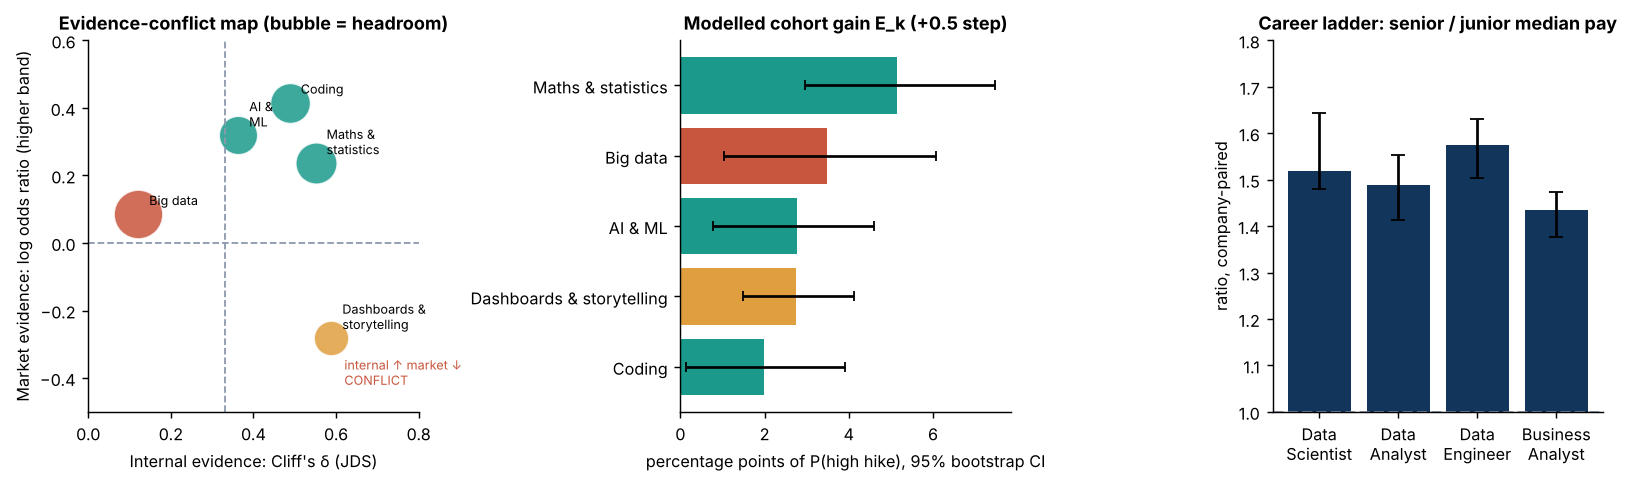

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.8))
col = {"FUND": C["teal"], "FUND WITH REFRAME": C["amber"], "MONITOR": C["grey"], "DEPRIORITISE": C["red"]}
for r in M.itertuples():
    ax[0].scatter(r.delta, np.log(r.OR_primary), s=r.headroom*9, color=col[r.verdict], alpha=.85, edgecolor="white")
    ax[0].annotate(r.capability.replace(" & ", " &\n"), (r.delta, np.log(r.OR_primary)), xytext=(6, 5), textcoords="offset points", fontsize=7)
ax[0].axhline(0, color=C["grey"], ls="--", lw=1); ax[0].axvline(0.33, color=C["grey"], ls="--", lw=1); ax[0].set_xlim(0, 0.8); ax[0].set_ylim(-0.5, 0.6)
ax[0].set_xlabel("Internal evidence: Cliff's δ (JDS)"); ax[0].set_ylabel("Market evidence: log odds ratio (higher band)"); ax[0].set_title("Evidence-conflict map (bubble = headroom)")
ax[0].text(0.62, -0.42, "internal ↑ market ↓\nCONFLICT", fontsize=7, color=C["red"])
m2 = M.sort_values("Ek"); ax[1].barh(m2.capability, m2.Ek, xerr=[m2.Ek-m2.Ek_lo, m2.Ek_hi-m2.Ek], color=[col[v] for v in m2.verdict], capsize=3); ax[1].set_title("Modelled cohort gain E_k (+0.5 step)"); ax[1].set_xlabel("percentage points of P(high hike), 95% bootstrap CI")
ld = pd.DataFrame(ladder).T; ax[2].bar([k.replace(" ", "\n") for k in ld.index], ld.median_ratio, yerr=[ld.median_ratio-ld.lo, ld.hi-ld.median_ratio], color=C["navy"], capsize=4)
ax[2].axhline(1, color=C["grey"], ls="--"); ax[2].set_ylim(1, 1.8); ax[2].set_title("Career ladder: senior / junior median pay"); ax[2].set_ylabel("ratio, company-paired")
plt.tight_layout(); plt.savefig("figs/fig06_decision.png", bbox_inches="tight"); plt.show()

## 4. Persist to a relational store and query the evidence (SQLite here; DDL is MySQL-compatible)

In [7]:
import sqlite3
con = sqlite3.connect("out/nexus_delta.db")
pd.read_csv("out/analytics_clean.csv", usecols=["s_no","job_desig","exp_min","exp_max","salary_ord","loc_tier","seniority","role_family","is_ds_p","is_ds_w"]).to_sql("analytics_clean", con, if_exists="replace", index=False)
JDS.to_sql("jds", con, if_exists="replace", index=False); DS.drop(columns=["company_top"]).to_sql("ds_jobs", con, if_exists="replace", index=False)
M.drop(columns=["key"]).to_sql("capability_evidence_matrix", con, if_exists="replace", index=False)
q = """SELECT capability, ROUND(delta,2) AS internal_delta, market, ROUND(headroom,0) AS headroom_pct, ROUND(Ek,2) AS gain_pp, verdict
       FROM capability_evidence_matrix ORDER BY Ek DESC"""
print(pd.read_sql(q, con).to_string(index=False))
q2 = "SELECT job_title, COUNT(*) AS rows_, ROUND(AVG(avg_salary),1) AS mean_LPA, SUM(num_of_jobs) AS postings FROM ds_jobs GROUP BY job_title ORDER BY mean_LPA DESC LIMIT 5"
print(); print(pd.read_sql(q2, con).to_string(index=False)); con.close()

               capability  internal_delta   market  headroom_pct  gain_pp           verdict
       Maths & statistics            0.55  Premium          59.0     5.15              FUND
                 Big data            0.12  Neutral          82.0     3.47      DEPRIORITISE
                  AI & ML            0.36  Premium          51.0     2.77              FUND
Dashboards & storytelling            0.59 Discount          42.0     2.75 FUND WITH REFRAME
                   Coding            0.49  Premium          55.0     1.98              FUND

              job_title  rows_  mean_LPA  postings
         Data Architect     50      25.1       528
  Senior Data Scientist    185      22.3      2129
   Senior Data Engineer    183      19.0      3411
         Data Scientist    188      13.5      9051
Senior Business Analyst    187      13.2     14115
